# Predictiv-Jee Model Evaluation
This notebook loads the dataset, uses the pre-trained Random Forest models, and provides complete visualization and evaluation of the models' performance (Actual vs. Predicted, Residual Analysis, Feature Importance, etc.).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import os
import sys

# Add src to path to import modules
sys.path.append('../src')
from data_loader import DataLoader

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")

## 1. Data Loading and Preprocessing
We will load the raw dataset and apply the same basic cleaning using our `DataLoader`.

In [25]:
# Initialize data loader
raw_path = '../data/raw/merged_jee_cutoff_2018_2025.parquet'
loader = DataLoader(raw_path)
df_raw = loader.load_data()

# Basic cleaning
# df_clean = loader.basic_clean()
df_clean = loader.clean_and_encode()

# Display sample
df_clean.sample(10)

Loading data from ../data/raw/merged_jee_cutoff_2018_2025.parquet...
Data successfully loaded. Shape: (Rows, Columns) (433993, 9)

----------------------------------------
3. CLEANING & ENCODING
----------------------------------------
Dropped 1469 rows due to missing Ranks.
Standardized 'Gender' column values.
Applying One-Hot Encoding to: ['Gender', 'Seat Type', 'Quota']
New Data Shape: (Rows, Columns) (432524, 25)


,Institute,Academic Program Name,Opening Rank,Closing Rank,Round,Year,Gender_Female-only (including Supernumerary),Gender_Gender-Neutral,Seat Type_EWS,Seat Type_EWS (PwD),...,Seat Type_SC (PwD),Seat Type_ST,Seat Type_ST (PwD),Quota_AI,Quota_AP,Quota_GO,Quota_HS,Quota_JK,Quota_LA,Quota_OS
1819,Indian Institute of Technology Palakkad,"Civil Engineering (4 Years, Bachelor of Techno...",4338.0,4338.0,1,2018,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
302606,Indian Institute of Technology Ropar,"Computer Science and Engineering (4 Years, Bac...",710.0,965.0,1,2023,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
366083,Maulana Azad National Institute of Technology ...,"Computer Science and Engineering (4 Years, Bac...",142.0,172.0,1,2025,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
364854,Indian Institute of Technology (BHU) Varanasi,"Civil Engineering (4 Years, Bachelor of Techno...",7201.0,9145.0,1,2025,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
81532,Indian Institute of Technology Kharagpur,"Economics (5 Years, Integrated Master of Science)",1895.0,2488.0,5,2019,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
422248,Indian Institute of Technology Bombay,"Applied Geophysics (4 Years, Bachelor of Science)",2950.0,2950.0,6,2025,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
10886,National Institute of Technology Patna,Electronics and Communication Engineering (4 Y...,543.0,543.0,2,2018,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
123800,"National Institute of Technology Karnataka, Su...",Electronics and Communication Engineering (4 Y...,2620.0,2620.0,3,2020,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
229474,"National Institute of Technology, Jamshedpur","Mechanical Engineering (4 Years, Bachelor of T...",3506.0,3506.0,5,2022,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
302640,Indian Institute of Technology Ropar,"Mathematics and Computing (4 Years, Bachelor o...",1595.0,1595.0,1,2023,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


## 2. Feature Processing & Model Loading
The features were preprocessed into two datasets: IITs and NITs/IIITs/GFTIs. We load the existing encoders to apply the transformations, and the pre-trained models.

In [27]:
if 'Opening Rank' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Opening Rank'])
        print("Dropped 'Opening Rank' to prevent data leakage.")
        
# Split into IITs and non-IITs dataframes => IITs are in one set of data and non-IITs are in another set of data
# This is done because IITs have their own admission criteria and they are different from non-IITs
# "Indian Institute of Technology" captures IITs (e.g. "Indian Institute of Technology Bombay")
# NITs, IIITs, and GFTIs will not match this string.
iit_mask = df_clean['Institute'].str.contains('Indian Institute of Technology', case=False, na=False)

df_iit = df_clean[iit_mask].copy()
df_nit = df_clean[~iit_mask].copy()

print(f"Data split complete:")
print(f"  -> IIT Dataset shape: {df_iit.shape}")
print(f"  -> NIT+ Dataset shape: {df_nit.shape}")
df_iit.info()
# categorical_data = ["Institute","Academic Program Name","Quota","Seat Type","Gender"]
categorical_data = ["Institute","Academic Program Name"]

Data split complete:
  -> IIT Dataset shape: (102876, 24)
  -> NIT+ Dataset shape: (329648, 24)
<class 'pandas.DataFrame'>
Index: 102876 entries, 0 to 425145
Data columns (total 24 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   Institute                                     102876 non-null  str    
 1   Academic Program Name                         102876 non-null  str    
 2   Closing Rank                                  102876 non-null  float64
 3   Round                                         102876 non-null  int64  
 4   Year                                          102876 non-null  int64  
 5   Gender_Female-only (including Supernumerary)  102876 non-null  int64  
 6   Gender_Gender-Neutral                         102876 non-null  int64  
 7   Seat Type_EWS                                 102876 non-null  int64  
 8   Seat Type_EWS (PwD)                         

In [28]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
for col in categorical_data:
    le = LabelEncoder()
    df_iit[col] = df_iit[col].astype(str)
    df_iit[col] = le.fit_transform(df_iit[col])

for col in categorical_data:
    le = LabelEncoder()
    df_nit[col] = df_nit[col].astype(str)
    df_nit[col] = le.fit_transform(df_nit[col])

df_iit.sample(10)
df_nit.sample(10)

,Institute,Academic Program Name,Closing Rank,Round,Year,Gender_Female-only (including Supernumerary),Gender_Gender-Neutral,Seat Type_EWS,Seat Type_EWS (PwD),Seat Type_OBC-NCL,...,Seat Type_SC (PwD),Seat Type_ST,Seat Type_ST (PwD),Quota_AI,Quota_AP,Quota_GO,Quota_HS,Quota_JK,Quota_LA,Quota_OS
241911,50,113,2064.0,6,2022,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
354191,34,189,3708.0,6,2023,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
331182,133,139,70531.0,3,2023,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
17163,97,234,843.0,3,2018,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
25668,113,139,1652.0,4,2018,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
11468,109,101,7897.0,2,2018,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
271215,80,89,4465.0,4,2024,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
116439,112,113,2982.0,2,2020,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
11239,106,146,13621.0,2,2018,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
390759,95,78,22570.0,3,2025,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import time
def split_train_evaluate(df,name):
    target = 'Closing Rank'
    y = df[target]
    X = df.drop(columns=[target])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    print(f"{name} Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"\nInitializing Random Forest Regressor for {name} (100 trees)...")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    print(f"Starting {name} training on {len(X_train)} rows. This may take a minute...")
    start_time = time.time()
    rf_model.fit(X_train, y_train)
    end_time = time.time()
    
    print(f"[SUCCESS] {name} Training Complete! It took {(end_time - start_time):.2f} seconds.")
    
    print(f"Evaluating {name} Model on Test Set...")
    y_pred = rf_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("-" * 40)
    print(f"{name} MODEL METRICS")
    print("-" * 40)
    print(f"Mean Absolute Error (MAE): {mae:.2f} ranks")
    print(f"R-squared (R²): {r2:.4f}")

In [ ]:
# iit_model with basic clean
split_train_evaluate(df_iit,"IIT_model")

IIT_model Train shape: (82300, 7), Test shape: (20576, 7)

Initializing Random Forest Regressor for IIT_model (100 trees)...
Starting IIT_model training on 82300 rows. This may take a minute...
[SUCCESS] IIT_model Training Complete! It took 2.29 seconds.
Evaluating IIT_model Model on Test Set...
----------------------------------------
IIT_model MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 76.58 ranks
R-squared (R²): 0.9976


In [ ]:
# nit_model with basic clean
split_train_evaluate(df_nit,"NIT_model")

NIT_model Train shape: (263718, 7), Test shape: (65930, 7)

Initializing Random Forest Regressor for NIT_model (100 trees)...
Starting NIT_model training on 263718 rows. This may take a minute...
[SUCCESS] NIT_model Training Complete! It took 14.88 seconds.
Evaluating NIT_model Model on Test Set...
----------------------------------------
NIT_model MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 1344.69 ranks
R-squared (R²): 0.9616


In [30]:
# iit_model with clean_and_encode
split_train_evaluate(df_iit,"IIT_MODEL")

IIT_MODEL Train shape: (82300, 23), Test shape: (20576, 23)

Initializing Random Forest Regressor for IIT_MODEL (100 trees)...
Starting IIT_MODEL training on 82300 rows. This may take a minute...
[SUCCESS] IIT_MODEL Training Complete! It took 2.70 seconds.
Evaluating IIT_MODEL Model on Test Set...
----------------------------------------
IIT_MODEL MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 76.31 ranks
R-squared (R²): 0.9976


In [32]:
#nit model with clean and encode
split_train_evaluate(df_nit,"NIT_MODEL")

NIT_MODEL Train shape: (263718, 23), Test shape: (65930, 23)

Initializing Random Forest Regressor for NIT_MODEL (100 trees)...
Starting NIT_MODEL training on 263718 rows. This may take a minute...
[SUCCESS] NIT_MODEL Training Complete! It took 27.66 seconds.
Evaluating NIT_MODEL Model on Test Set...
----------------------------------------
NIT_MODEL MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 1317.19 ranks
R-squared (R²): 0.9617


### Loading the presaved pickle encoded files

In [33]:
import joblib
import pickle
# Load Models
print("Loading IIT Model...")
iit_model = joblib.load('../models/iit_model.pkl')
print("Loading NIT Model...")
nit_model = joblib.load('../models/nit_model.pkl')

# Load Encoders
with open('../models/iit_encoders.pkl', 'rb') as f:
    iit_encoders = pickle.load(f)

with open('../models/nit_encoders.pkl', 'rb') as f:
    nit_encoders = pickle.load(f)

Loading IIT Model...
Loading NIT Model...


## 3. Predictions and Metrics
We will calculate predictions for both datasets and evaluate standard metrics like Mean Absolute Error (MAE) and R-squared.

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def evaluate_predictions(df_encoded, model, name):
    X = df_encoded.drop(columns=['Closing Rank'])
    y_true = df_encoded['Closing Rank']
    
    print(f"Generating predictions for {name}...")
    y_pred = model.predict(X)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print("-" * 40)
    print(f"{name} MODEL METRICS")
    print("-" * 40)
    print(f"Mean Absolute Error (MAE): {mae:.2f} ranks")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} ranks")
    print(f"R-squared (R�): {r2:.4f}")
    
    return y_true, y_pred, X

y_true_iit, y_pred_iit, X_iit = evaluate_predictions(df_iit_encoded, iit_model, "IIT")
y_true_nit, y_pred_nit, X_nit = evaluate_predictions(df_nit_encoded, nit_model, "NIT/IIIT/GFTI")

Generating predictions for IIT...
----------------------------------------
IIT MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 38.14 ranks
Root Mean Squared Error (RMSE): 114.58 ranks
R-squared (R�): 0.9993
Generating predictions for NIT/IIIT/GFTI...
----------------------------------------
NIT/IIIT/GFTI MODEL METRICS
----------------------------------------
Mean Absolute Error (MAE): 689.56 ranks
Root Mean Squared Error (RMSE): 5521.77 ranks
R-squared (R�): 0.9863


## 4. Visualizations

### 4.1 Actual vs. Predicted Values
A scatter plot allows us to visually inspect how well our predictions align with the actual closing ranks. The red dashed line represents a perfect prediction (y = x).

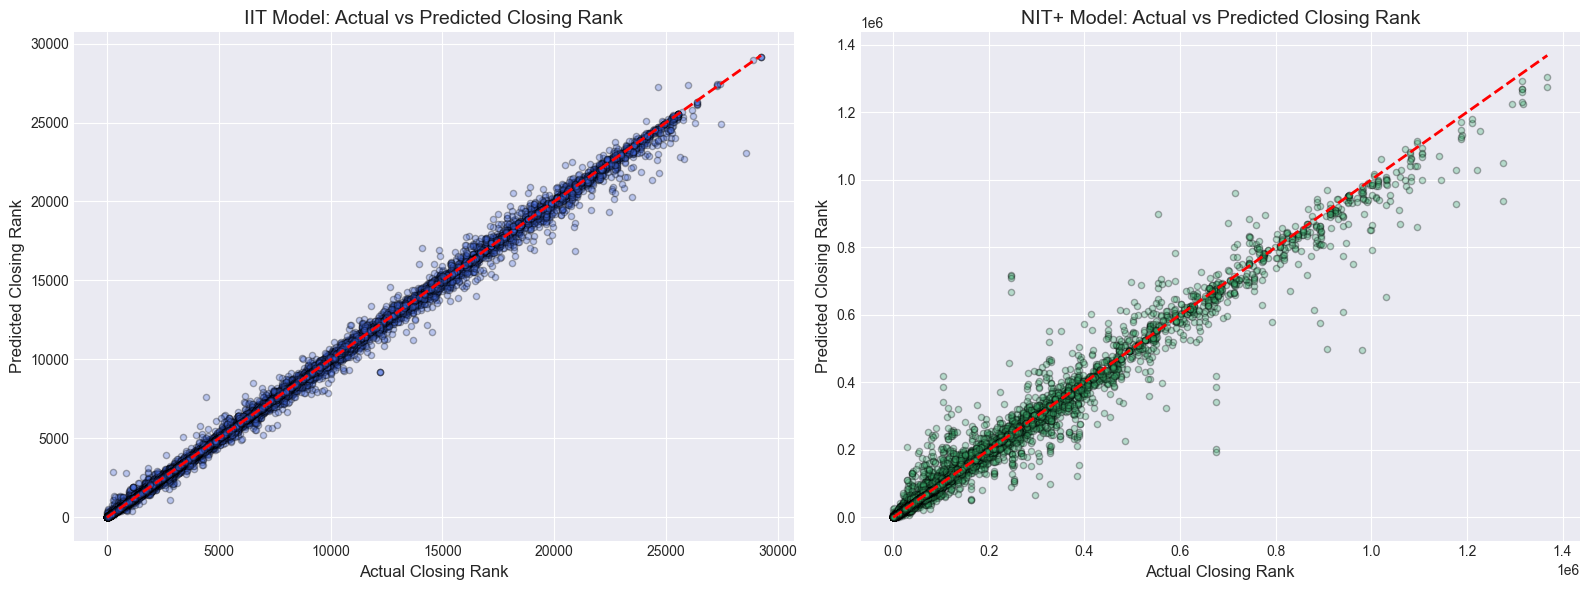

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# IIT Scatter
ax[0].scatter(y_true_iit, y_pred_iit, alpha=0.3, color='royalblue', edgecolor='k', s=20)
ax[0].plot([y_true_iit.min(), y_true_iit.max()], [y_true_iit.min(), y_true_iit.max()], 'r--', lw=2)
ax[0].set_title('IIT Model: Actual vs Predicted Closing Rank', fontsize=14)
ax[0].set_xlabel('Actual Closing Rank', fontsize=12)
ax[0].set_ylabel('Predicted Closing Rank', fontsize=12)

# NIT Scatter
ax[1].scatter(y_true_nit, y_pred_nit, alpha=0.3, color='mediumseagreen', edgecolor='k', s=20)
ax[1].plot([y_true_nit.min(), y_true_nit.max()], [y_true_nit.min(), y_true_nit.max()], 'r--', lw=2)
ax[1].set_title('NIT+ Model: Actual vs Predicted Closing Rank', fontsize=14)
ax[1].set_xlabel('Actual Closing Rank', fontsize=12)
ax[1].set_ylabel('Predicted Closing Rank', fontsize=12)

plt.tight_layout()
plt.show()

### 4.2 Residual Analysis
Analyzing the distribution of residuals (errors) can tell us if the model is systematically over- or under-predicting. A balanced model should have a residual distribution centered around 0.

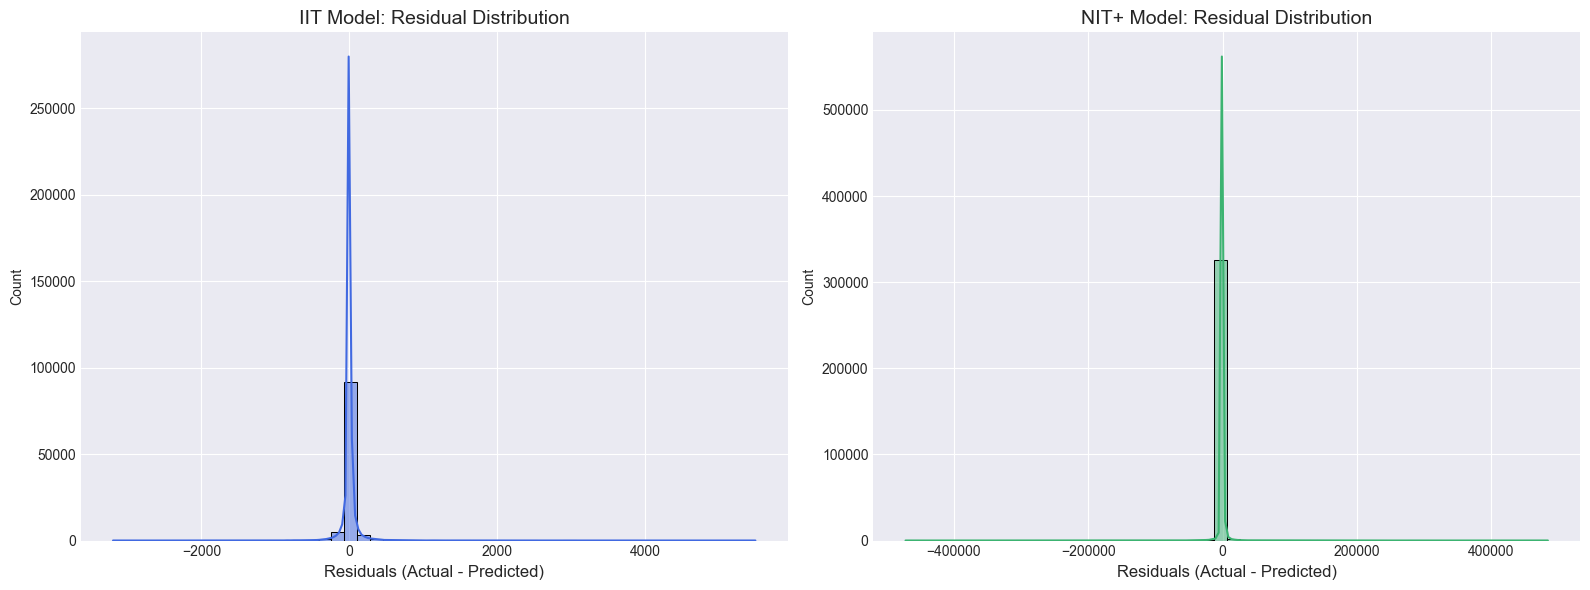

In [36]:
residuals_iit = y_true_iit - y_pred_iit
residuals_nit = y_true_nit - y_pred_nit

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# IIT Residuals
sns.histplot(residuals_iit, bins=50, kde=True, ax=ax[0], color='royalblue')
ax[0].set_title('IIT Model: Residual Distribution', fontsize=14)
ax[0].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)

# NIT Residuals
sns.histplot(residuals_nit, bins=50, kde=True, ax=ax[1], color='mediumseagreen')
ax[1].set_title('NIT+ Model: Residual Distribution', fontsize=14)
ax[1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)

plt.tight_layout()
plt.show()

### 4.3 Feature Importance
Let's examine which features the Random Forest models consider most important when predicting the closing rank.

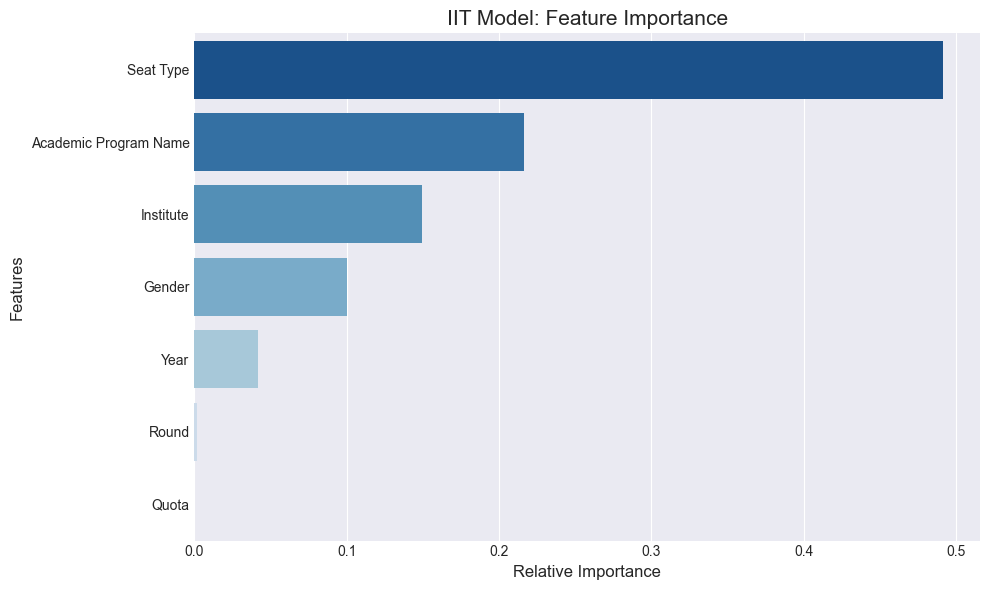

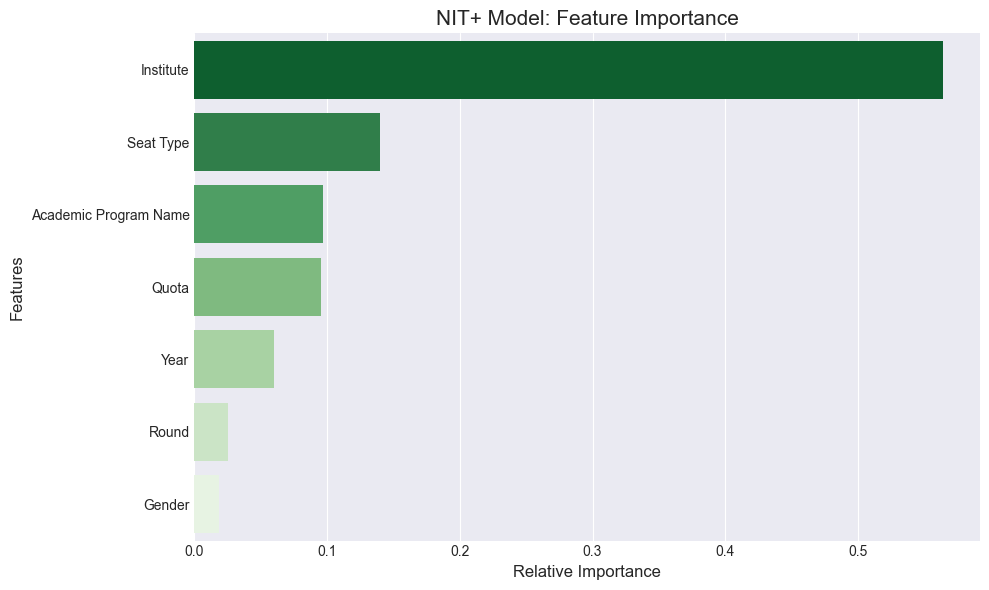

In [37]:
def plot_feature_importance(model, features, title, color):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=[features[i] for i in indices], hue=[features[i] for i in indices], palette=color, legend=False)
    plt.title(title, fontsize=15)
    plt.xlabel('Relative Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_feature_importance(iit_model, X_iit.columns, "IIT Model: Feature Importance", "Blues_r")
plot_feature_importance(nit_model, X_nit.columns, "NIT+ Model: Feature Importance", "Greens_r")

### 4.4 Error Over Time (Yearly Trends)
By examining the absolute prediction error over the years, we can check if the model struggles with older data compared to newer data (or vice-versa).

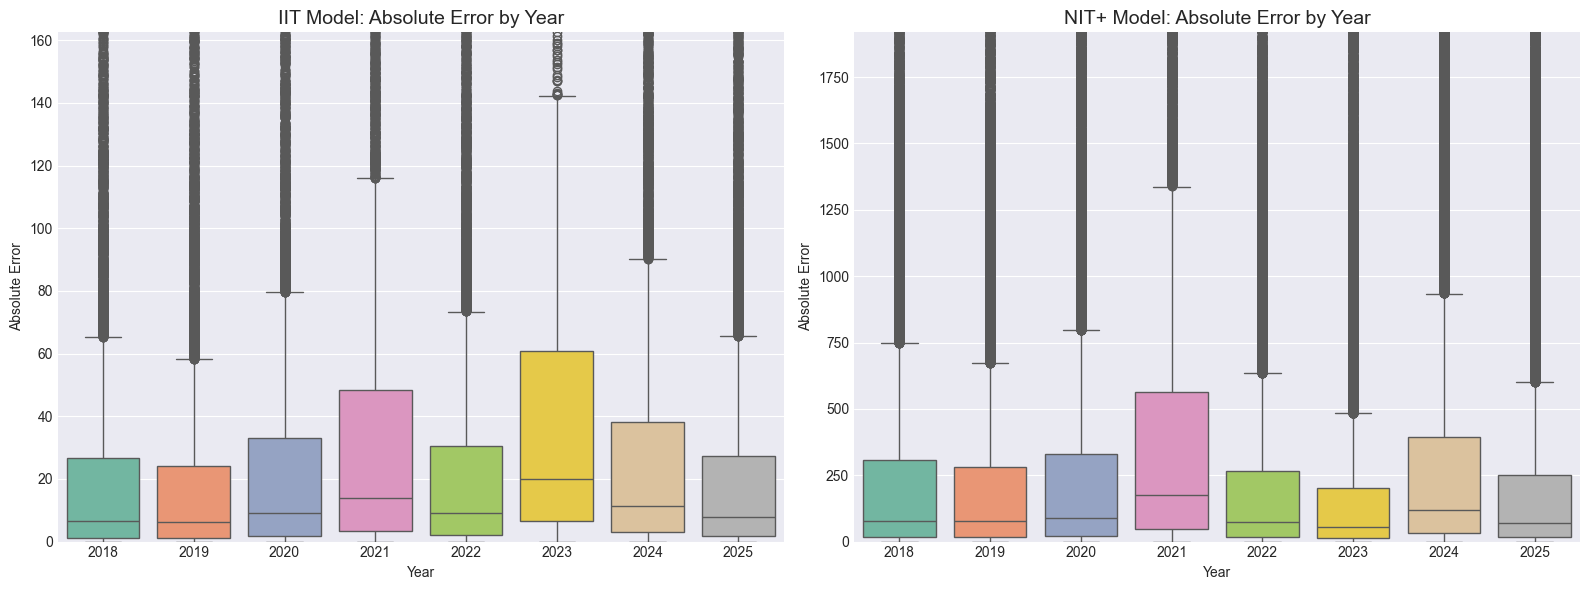

In [38]:
# Add Year and Residuals to the dataframes for analysis
df_iit_eval = df_iit.copy()
df_iit_eval['Absolute Error'] = np.abs(residuals_iit)

df_nit_eval = df_nit.copy()
df_nit_eval['Absolute Error'] = np.abs(residuals_nit)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Year', y='Absolute Error', data=df_iit_eval, ax=ax[0], palette="Set2", hue='Year', legend=False)
ax[0].set_title('IIT Model: Absolute Error by Year', fontsize=14)
ax[0].set_ylim(0, np.percentile(df_iit_eval['Absolute Error'], 95))

sns.boxplot(x='Year', y='Absolute Error', data=df_nit_eval, ax=ax[1], palette="Set2", hue='Year', legend=False)
ax[1].set_title('NIT+ Model: Absolute Error by Year', fontsize=14)
ax[1].set_ylim(0, np.percentile(df_nit_eval['Absolute Error'], 95))

plt.tight_layout()
plt.show()